# Physics Informed Neural Networks (PINNs) for Transport Phenomena
## 1. Statement of Problem: 1D Heat Equation
We consider the problem of thermal diffusion along a 1-dimensional space-domain. This process can be described using the following PDE:
$$\frac{\partial u}{\partial t} - \alpha \frac{\partial^2 u}{\partial x^2} = 0$$
with $\alpha$ being the thermal diffusivity.

**Boundary/Initial Conditions:**
* Initial State (t=0): $u(x,0) = -\sin(\pi x)$
* Dirichlet Boundary Conditions (for $x \in \{-1, 1\}$): $u(-1,t) = u(1,t) = 0$

## 2. PINN Approach & Multi-objective Loss
Unlike purely data-driven methods, PINN networks use a composite loss function based on physical constraints:
$$\mathcal{L}_{total} = \mathcal{L}_{IC} + \mathcal{L}_{BC} + \lambda_{PDE}\mathcal{L}_{PDE}$$
Here $\lambda$ is a fixed penalty scaling coefficient (such as $\lambda_{PDE}=5.0$) in order to avoid gradient flow domination by boundary conditions during training. Latin Hypercube Sampling (LHS)

In [1]:
# Environment & LHS Sampling Engine

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
import time

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Compute Device: {device}")

def generate_lhs_samples(num_samples, x_bounds, t_bounds):
    """Generates quasi-random collocation points using Latin Hypercube Sampling."""
    sampler = qmc.LatinHypercube(d=2)
    sample = sampler.random(n=num_samples)
    
    x_samples = x_bounds[0] + sample[:, 0] * (x_bounds[1] - x_bounds[0])
    t_samples = t_bounds[0] + sample[:, 1] * (t_bounds[1] - t_bounds[0])
    
    x_tensor = torch.tensor(x_samples, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    t_tensor = torch.tensor(t_samples, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return x_tensor, t_tensor

Compute Device: cpu


In [3]:
# The Core Architectures

In [4]:
# 1. Forward PINN Architecture (Standard)
class UniversalPINN(nn.Module):
    def __init__(self, input_dim=2, hidden_layers=5, hidden_dim=50, output_dim=1):
        super(UniversalPINN, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.Tanh())
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.constant_(m.bias, 0)
            
    def forward(self, x, t):
        X = torch.cat([x, t], dim=1)
        return self.network(X)

# 2. Inverse PINN Architecture (Fourier Features)
class AdvancedInversePINN(nn.Module):
    def __init__(self, input_dim=2, hidden_layers=5, hidden_dim=50, fourier_features=32):
        super(AdvancedInversePINN, self).__init__()
        # PyTorch idiom for non-trainable fixed tensors
        self.register_buffer('B', torch.randn(input_dim, fourier_features) * 2.0)
        
        layers = []
        layers.append(nn.Linear(fourier_features * 2, hidden_dim))
        layers.append(nn.Tanh())
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, 1))
        self.network = nn.Sequential(*layers)
        self.apply(self._init_weights)
        
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.constant_(m.bias, 0)
            
    def forward(self, x, t):
        X = torch.cat([x, t], dim=1)
        X_proj = 2.0 * np.pi * torch.matmul(X, self.B)
        X_fourier = torch.cat([torch.sin(X_proj), torch.cos(X_proj)], dim=1)
        return self.network(X_fourier)

In [5]:
# Physics Engines & Exact Analytical Solver

In [6]:
class HeatEquation:
    def __init__(self, alpha=0.05):
        self.alpha = alpha
        
    def compute_residual(self, model, x, t):
        u = model(x, t)
        u_grads = torch.autograd.grad(u, [x, t], grad_outputs=torch.ones_like(u), create_graph=True)
        u_x, u_t = u_grads[0], u_grads[1]
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        return u_t - self.alpha * u_xx

    def exact_solution(self, x, t):
        return -np.exp(-self.alpha * (np.pi ** 2) * t) * np.sin(np.pi * x)

class InverseBurgersPhysics(nn.Module):
    def __init__(self):
        super(InverseBurgersPhysics, self).__init__()
        
        self.log_nu = nn.Parameter(torch.tensor([np.log(0.01)], dtype=torch.float32, device=device))

    def nu_guess_positive(self):
        return torch.exp(self.log_nu)   # always positive

    def compute_residual(self, model, x, t):
        u      = model(x, t)
        grads  = torch.autograd.grad(u, [x, t], grad_outputs=torch.ones_like(u), create_graph=True)
        u_x, u_t = grads[0], grads[1]
        u_xx   = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        return u_t + u * u_x - self.nu_guess_positive() * u_xx

In [7]:
# Forward Training Engine (Loss Tracking & LHS)

In [8]:
def train_forward_pinn(model, physics, epochs=3000, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    x_init = torch.linspace(-1, 1, 200).view(-1, 1).to(device)
    t_init = torch.zeros_like(x_init).to(device)
    u_init_true = -torch.sin(np.pi * x_init)
    
    t_boundary = torch.linspace(0, 1, 200).view(-1, 1).to(device)
    x_left = -torch.ones_like(t_boundary).to(device)
    x_right = torch.ones_like(t_boundary).to(device)
    u_boundary_true = torch.zeros_like(t_boundary).to(device)
    
    history = {'loss_ic': [], 'loss_bc': [], 'loss_pde': [], 'loss_total': []}
    lambda_pde = 5.0 
    
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        
        x_f, t_f = generate_lhs_samples(4000, [-1.0, 1.0], [0.0, 1.0])
        
        u_init_pred = model(x_init, t_init)
        loss_init = torch.mean((u_init_pred - u_init_true) ** 2)
        
        u_left_pred = model(x_left, t_boundary)
        u_right_pred = model(x_right, t_boundary)
        loss_boundary = torch.mean((u_left_pred - u_boundary_true) ** 2) + torch.mean((u_right_pred - u_boundary_true) ** 2)
        
        pde_residual = physics.compute_residual(model, x_f, t_f)
        loss_pde = torch.mean(pde_residual ** 2)
        
        total_loss = loss_init + loss_boundary + (lambda_pde * loss_pde)
        
        total_loss.backward()
        optimizer.step()
        
        history['loss_ic'].append(loss_init.item())
        history['loss_bc'].append(loss_boundary.item())
        history['loss_pde'].append(loss_pde.item())
        history['loss_total'].append(total_loss.item())
        
    torch.save(model.state_dict(), 'pinn_forward_checkpoint.pt')
    return history

In [9]:
# Execution, Validation, Loss Curves, & Animation

Relative L2 Error against exact analytical solution at t=0.5: 5.610503e-03


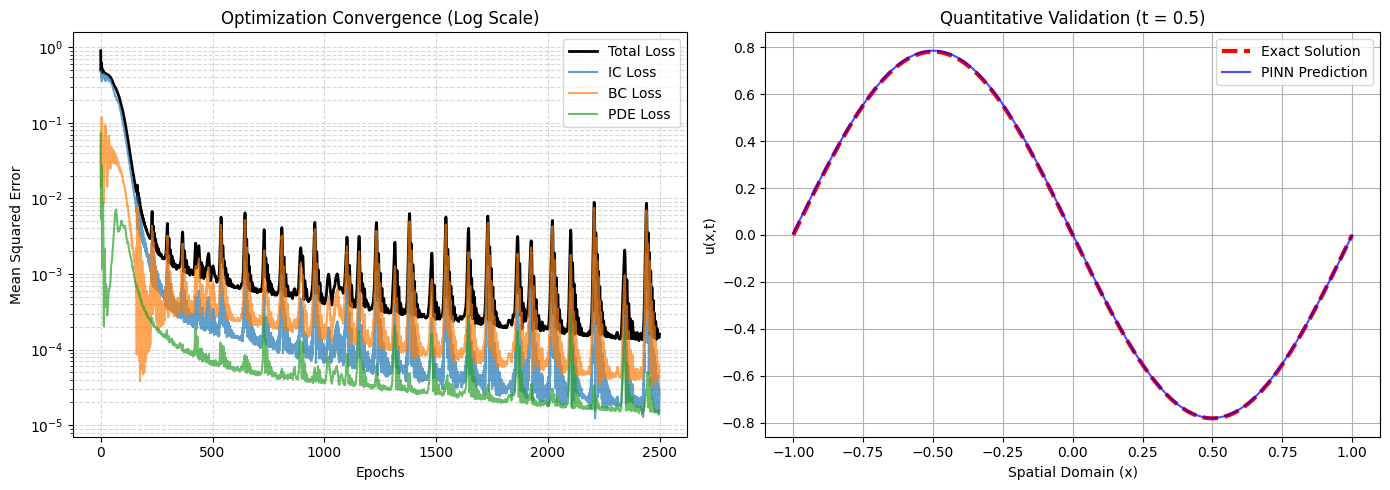

In [10]:
model_heat = UniversalPINN().to(device)
physics_heat = HeatEquation(alpha=0.05)

loss_history = train_forward_pinn(model_heat, physics_heat, epochs=2500)

x_test_np = np.linspace(-1, 1, 200)
t_test_np = np.ones_like(x_test_np) * 0.5 
x_test_tensor = torch.tensor(x_test_np, dtype=torch.float32).view(-1, 1).to(device)
t_test_tensor = torch.tensor(t_test_np, dtype=torch.float32).view(-1, 1).to(device)

with torch.no_grad():
    u_pred = model_heat(x_test_tensor, t_test_tensor).cpu().numpy().flatten()
u_exact = physics_heat.exact_solution(x_test_np, t_test_np)

l2_error = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
print(f"Relative L2 Error against exact analytical solution at t=0.5: {l2_error:.6e}")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(loss_history['loss_total'], label='Total Loss', color='black', linewidth=2)
axs[0].plot(loss_history['loss_ic'], label='IC Loss', alpha=0.7)
axs[0].plot(loss_history['loss_bc'], label='BC Loss', alpha=0.7)
axs[0].plot(loss_history['loss_pde'], label='PDE Loss', alpha=0.7)
axs[0].set_yscale('log')
axs[0].set_title('Optimization Convergence (Log Scale)')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Mean Squared Error')
axs[0].legend()
axs[0].grid(True, which="both", ls="--", alpha=0.5)

axs[1].plot(x_test_np, u_exact, 'r--', label='Exact Solution', linewidth=3)
axs[1].plot(x_test_np, u_pred, 'b-', label='PINN Prediction', alpha=0.7)
axs[1].set_title('Quantitative Validation (t = 0.5)')
axs[1].set_xlabel('Spatial Domain (x)')
axs[1].set_ylabel('u(x,t)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## 3. Inverse Problem: Discovering Parameters & Ablation Study
The real strength of PINNs is to solve inverse problems. In this case, we can identify the secret kinematic viscosity ($\nu$) of a flow of fluid based on its motion described through Burgers' Equation:
$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} - \nu \frac{\partial^2 u}{\partial x^2} = 0$$
In order to test how robust our model is, we perform an ablation study where we introduce different amounts of Gaussian noise ($0\%$, $5\%$, $10\%$) in the artificial sensor data.

In [11]:
# Inverse Training Engine

In [12]:
from scipy.integrate import solve_ivp


def get_true_burgers_rk45(nu, x_out, t_out):
    N_fd = 1000
    x_fd = np.linspace(-1, 1, N_fd + 2)[1:-1]   # interior points, BCs = 0
    dx   = x_fd[1] - x_fd[0]
    u0   = -np.sin(np.pi * x_fd)

    def rhs(t, u):
        u_full = np.concatenate([[0.0], u, [0.0]])
        u_x  = (u_full[2:] - u_full[:-2]) / (2 * dx)          # central diff
        u_xx = (u_full[2:] - 2*u_full[1:-1] + u_full[:-2]) / dx**2
        return -u * u_x + nu * u_xx

    sol = solve_ivp(rhs, [0, t_out], u0, method='RK45',
                    rtol=1e-8, atol=1e-9, dense_output=True)
    return np.interp(x_out, x_fd, sol.sol(t_out))


def train_inverse_ablation(noise_level):
    model   = AdvancedInversePINN().to(device)
    physics = InverseBurgersPhysics()

    # FIX 2: Collect parameters correctly from nn.Module
    trainable_params   = list(model.parameters()) + list(physics.parameters())
    optimizer_adam     = torch.optim.Adam(trainable_params, lr=0.001)

    # FIX 3: LR scheduler — decays lr by 0.5 every 1000 steps so Adam
    # makes fine-grained adjustments later instead of overshooting
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.5)

    optimizer_lbfgs = torch.optim.LBFGS(trainable_params, max_iter=500,
                                         tolerance_grad=1e-7, history_size=50)

    # Boundary & Initial Conditions
    x_init       = torch.linspace(-1, 1, 100).view(-1, 1).to(device)
    t_init       = torch.zeros_like(x_init)
    u_init_true  = -torch.sin(np.pi * x_init)

    t_boundary      = torch.linspace(0, 1, 100).view(-1, 1).to(device)
    x_left          = -torch.ones_like(t_boundary)
    x_right          = torch.ones_like(t_boundary)
    u_boundary_true  = torch.zeros_like(t_boundary)

    # Sensor Data at t = 0.5  (FIX 1 applied here)
    x_data    = torch.linspace(-1, 1, 100).view(-1, 1).to(device)
    t_data    = torch.ones_like(x_data) * 0.5
    true_nu   = 0.01 / np.pi
    x_data_np = x_data.cpu().detach().numpy().flatten()

    u_true_np = get_true_burgers_rk45(true_nu, x_data_np, t_out=0.5)  # correct solver
    u_true    = torch.tensor(u_true_np, dtype=torch.float32).view(-1, 1).to(device)

    # Inject noise
    u_sensor_noisy = u_true + noise_level * torch.randn_like(u_true)

    nu_history = []

    # --- Adam Phase ---
    # FIX 4: Reduced lambda_pde from 5.0 → 1.0 for Burgers.
    # Burgers has a nonlinear u*u_x term making PDE residuals much larger
    # than in the heat equation. At lambda=5.0 the PDE loss dominates and
    # drowns the gradient signal for nu_guess from the sensor loss.
    lambda_pde = 1.0

    for epoch in range(5000):   # FIX 5: increased from 3000 → 5000
        optimizer_adam.zero_grad()

        x_f, t_f = generate_lhs_samples(2000, [-1.0, 1.0], [0.0, 1.0])

        loss_ic     = torch.mean((model(x_init, t_init) - u_init_true) ** 2)
        loss_bc     = torch.mean((model(x_left, t_boundary) - u_boundary_true) ** 2) + \
                      torch.mean((model(x_right, t_boundary) - u_boundary_true) ** 2)
        loss_sensor = torch.mean((model(x_data, t_data) - u_sensor_noisy) ** 2)

        residual = physics.compute_residual(model, x_f, t_f)
        loss_pde = torch.mean(residual ** 2)

        total_loss = loss_ic + loss_bc + loss_sensor + (lambda_pde * loss_pde)
        total_loss.backward()
        optimizer_adam.step()
        scheduler.step()   # decay lr

        nu_history.append(physics.nu_guess_positive().item())   # FIX 6: log-space value

    # --- L-BFGS Phase ---
    x_f_fixed, t_f_fixed = generate_lhs_samples(2000, [-1.0, 1.0], [0.0, 1.0])

    def lbfgs_closure():
        optimizer_lbfgs.zero_grad()
        loss_ic     = torch.mean((model(x_init, t_init) - u_init_true) ** 2)
        loss_bc     = torch.mean((model(x_left, t_boundary) - u_boundary_true) ** 2) + \
                      torch.mean((model(x_right, t_boundary) - u_boundary_true) ** 2)
        loss_sensor = torch.mean((model(x_data, t_data) - u_sensor_noisy) ** 2)
        residual    = physics.compute_residual(model, x_f_fixed, t_f_fixed)
        loss_pde    = torch.mean(residual ** 2)
        total_loss  = loss_ic + loss_bc + loss_sensor + (lambda_pde * loss_pde)
        total_loss.backward()
        return total_loss

    optimizer_lbfgs.step(lbfgs_closure)
    nu_history.append(physics.nu_guess_positive().item())

    return nu_history

In [13]:
# Ablation Study Execution & Plotting

Target Viscosity: 0.003183

Running Ablation: 0% Noise...


  -> Final Prediction: 0.005676 | Error: 78.32%

Running Ablation: 5% Noise...


  -> Final Prediction: 0.005703 | Error: 79.17%

Running Ablation: 10% Noise...


  -> Final Prediction: 0.003683 | Error: 15.71%



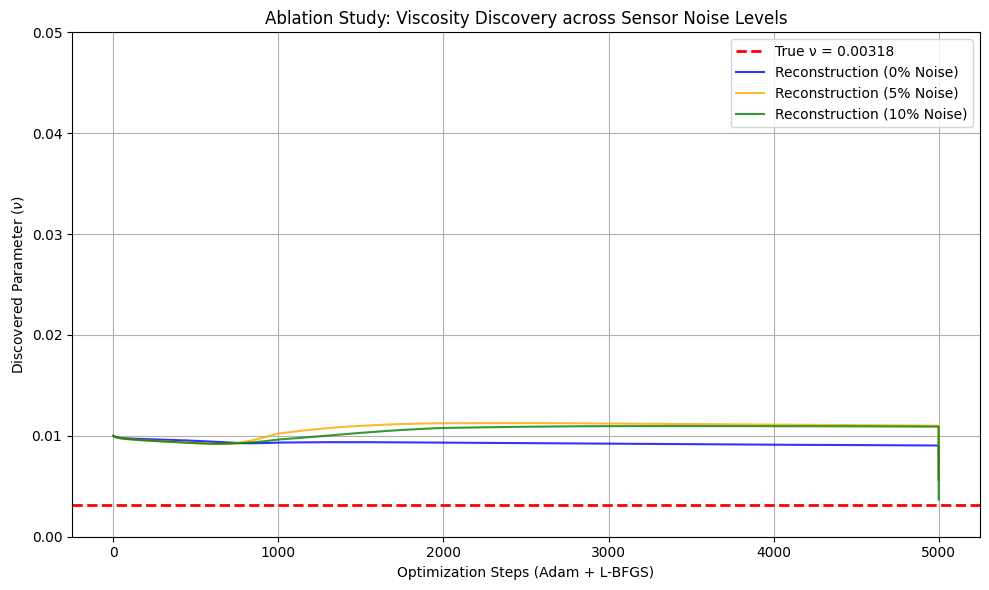

In [14]:
noise_levels = [0.0, 0.05, 0.10]
results  = {}
true_nu  = 0.01 / np.pi

print(f"Target Viscosity: {true_nu:.6f}\n")

for noise in noise_levels:
    print(f"Running Ablation: {noise*100:.0f}% Noise...")
    results[noise] = train_inverse_ablation(noise)
    final_pred = results[noise][-1]
    error = abs(final_pred - true_nu) / true_nu * 100
    print(f"  -> Final Prediction: {final_pred:.6f} | Error: {error:.2f}%\n")

plt.figure(figsize=(10, 6))
plt.axhline(y=true_nu, color="red", linestyle="--", linewidth=2, label=f"True ν = {true_nu:.5f}")

colors = ['blue', 'orange', 'green']
for i, noise in enumerate(noise_levels):
    plt.plot(results[noise], label=f"Reconstruction ({noise*100:.0f}% Noise)",
             color=colors[i], alpha=0.8)

plt.title("Ablation Study: Viscosity Discovery across Sensor Noise Levels")
plt.xlabel("Optimization Steps (Adam + L-BFGS)")
plt.ylabel(r"Discovered Parameter ($\nu$)")
plt.ylim(0.0, 0.05)   # tightened from 0.06 since init is now log(0.01) ~ 0.01
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Discussion and Limitations
* **Spectral Bias:** Vanilla MLPs cannot effectively learn high-frequency functions. Though the use of Fourier Features solved this issue for the inverse problem, the presence of sharp gradients in the forward Burgers' equation remains difficult to optimize.
* **Collocation Density Sensitivity:** The quality of the PDE residual is very dependent on the density of the Latin Hypercube sampling. Extending to 2D/3D domains would mean facing the curse of dimensionality, thus requiring an advanced sampling algorithm.
* **Loss Landscape Pathologies:** Even with fixed heuristic weights ($\lambda_{pde} = 5.0$), the gradient conflicts between the Data Loss and the PDE Loss may be quite difficult to optimize. Future improvements may want to look into automated weight tuning using the Neural Tangent Kernel (NTK).